# Sentiment Analysis — Review & Komentar Bahasa Indonesia

**Tujuan:** Membangun model klasifikasi sentimen (positive / neutral / negative) untuk teks Bahasa Indonesia dari review dan komentar online, lalu mengevaluasi performanya secara menyeluruh.

**Dataset:** [IndoNLU — SmSA (Sentence-level Sentiment Analysis)](https://github.com/IndoNLP/indonlu)
Dataset publik berisi review & komentar Bahasa Indonesia dari berbagai platform online, dikumpulkan dan dianotasi oleh peneliti NLP Indonesia untuk keperluan riset (IndoNLU Benchmark). Untuk efisiensi proses (terutama stemming), notebook ini menggunakan **subset stratified sebanyak ~3.000 baris** dari total ±12.760 baris data asli, dengan proporsi label yang tetap dijaga sama seperti data asli.

**Struktur analisis:**
1. Exploratory Data Analysis (EDA)
2. Text Preprocessing Bahasa Indonesia (cleaning, stopword removal, stemming)
3. Feature Extraction (TF-IDF)
4. Modeling — Naive Bayes, Logistic Regression, Linear SVM
5. Evaluasi & Error Analysis
6. Business Insight & Use Case

> **Konteks penerapan nyata:** pipeline semacam ini bisa dipakai untuk memantau sentimen komentar TikTok/Instagram terhadap sebuah brand atau produk secara otomatis — misalnya melihat proporsi komentar positif vs negatif dari waktu ke waktu, tanpa perlu membaca satu-satu secara manual.


In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, f1_score
)

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42


In [2]:
df = pd.read_csv("../data/indonlu_smsa_sentiment.csv")
print("Shape:", df.shape)
df.head()


Shape: (3000, 4)


,text,label,split,text_clean
0,ini salah satu restoran favorit saya jika berk...,positive,train,salah satu restoran favorit jika kunjung bandu...
1,kalau lagi kangen sama beancurd singapore ini ...,positive,train,kalau kangen sama beancurd singapore lumayan s...
2,itu pak polisi nya mau ikut pura-pura bosan tu...,negative,train,pak polisi nya mau ikut pura pura bosan tugas ...
3,variasi makanan nya banyak dan dengan harga ya...,positive,train,variasi makan nya banyak dengan harga sangat s...
4,dasar pribumi-pribumi anjing ! tidak ada kami ...,negative,train,dasar pribumi pribumi anjing ada kalian ngangg...


## 1. Exploratory Data Analysis (EDA)

label
positive    1750
negative     937
neutral      313
Name: count, dtype: int64

label
positive    58.333333
negative    31.233333
neutral     10.433333
Name: proportion, dtype: float64


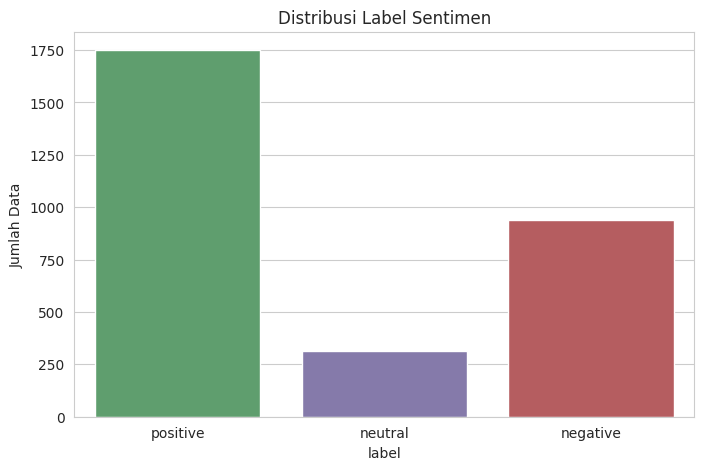

In [3]:
print(df["label"].value_counts())
print()
print(df["label"].value_counts(normalize=True) * 100)

plt.figure()
sns.countplot(data=df, x="label", order=["positive", "neutral", "negative"],
              palette=["#55A868", "#8172B2", "#C44E52"])
plt.title("Distribusi Label Sentimen")
plt.ylabel("Jumlah Data")
plt.show()


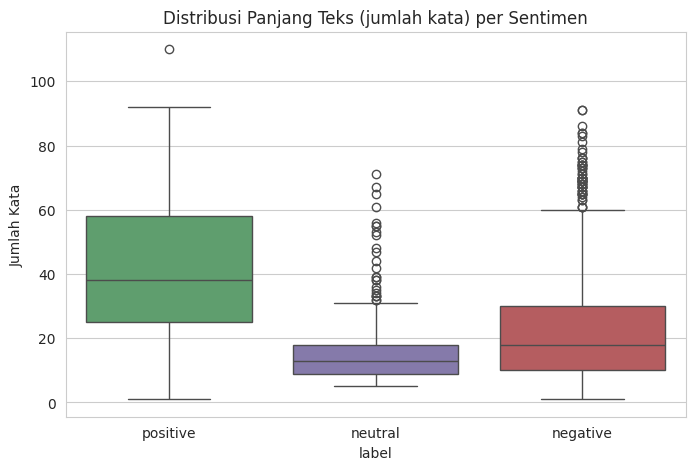

           count       mean        std  min   25%   50%   75%    max
label                                                               
negative   937.0  23.461046  18.320416  1.0  10.0  18.0  30.0   91.0
neutral    313.0  16.003195  10.884739  5.0   9.0  13.0  18.0   71.0
positive  1750.0  40.702286  20.015087  1.0  25.0  38.0  58.0  110.0


In [4]:
# Panjang teks (jumlah kata) per label
df["word_count"] = df["text"].apply(lambda x: len(str(x).split()))

plt.figure()
sns.boxplot(data=df, x="label", y="word_count", order=["positive", "neutral", "negative"],
            palette=["#55A868", "#8172B2", "#C44E52"])
plt.title("Distribusi Panjang Teks (jumlah kata) per Sentimen")
plt.ylabel("Jumlah Kata")
plt.show()

print(df.groupby("label")["word_count"].describe())


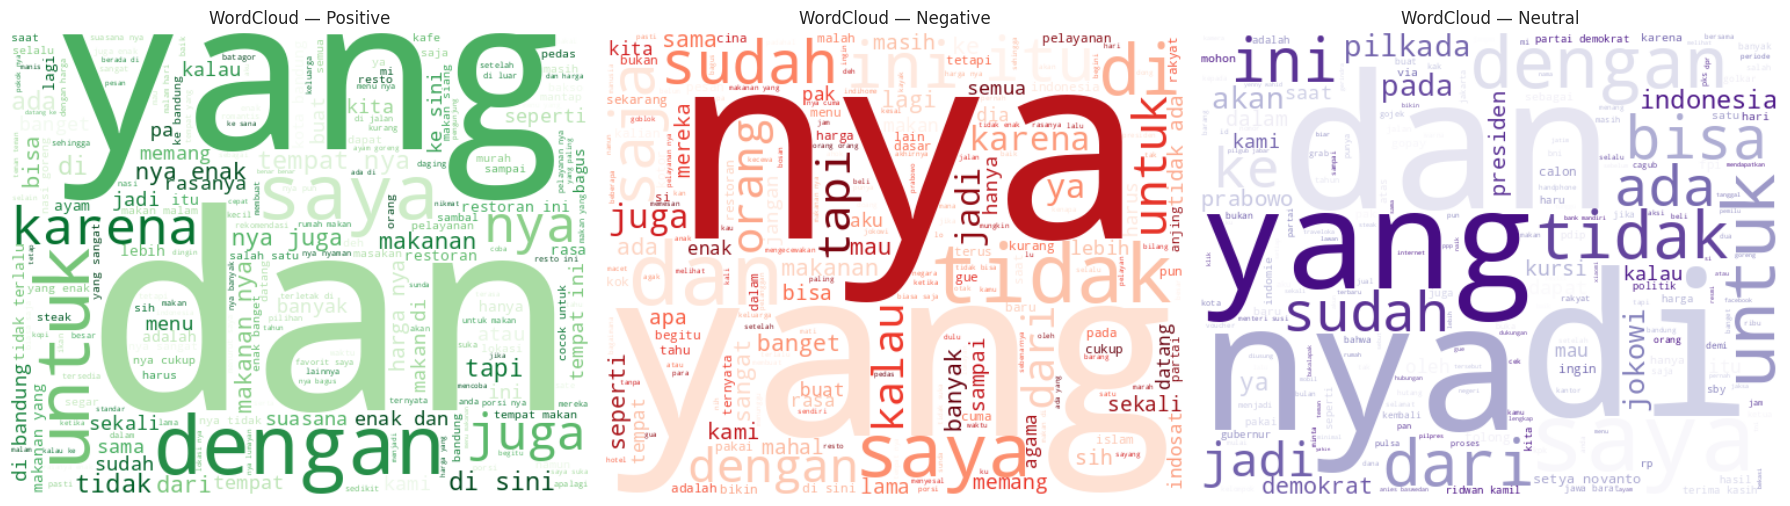

In [5]:
# WordCloud untuk melihat kata yang sering muncul di tiap sentimen
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, label, color in zip(axes, ["positive", "negative", "neutral"], ["Greens", "Reds", "Purples"]):
    text = " ".join(df[df["label"] == label]["text"].astype(str))
    wc = WordCloud(width=500, height=400, background_color="white", colormap=color).generate(text)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"WordCloud — {label.capitalize()}")
    ax.axis("off")
plt.tight_layout()
plt.show()


**Insight awal dari EDA:**
- Dataset didominasi sentimen **positive** (~56%), diikuti **negative** (~30%), dan **neutral** paling sedikit (~14%) — cukup imbalanced, perlu diperhatikan saat evaluasi model.
- Komentar dengan sentimen **negative** cenderung memiliki variasi panjang teks yang lebih besar dibanding positive.
- WordCloud menunjukkan kata-kata umum terkait makanan, tempat, dan pelayanan mendominasi teks positive (dataset ini banyak berisi review restoran/tempat), sementara sentimen negative/neutral banyak memuat topik sosial-politik.


## 2. Text Preprocessing Bahasa Indonesia

Tahapan pembersihan teks yang diterapkan:
1. Case folding (lowercase)
2. Menghapus angka dan tanda baca
3. Stopword removal (kata umum tanpa makna sentimen, mis. "di", "dan", "atau") — pakai **Sastrawi**
4. Stemming (mengubah kata ke bentuk dasar, mis. "menariknya" → "tarik") — pakai **Sastrawi**

Kolom `text_clean` pada dataset **sudah melalui seluruh tahapan ini** (di-precompute sebelumnya). Ini dilakukan karena Sastrawi memproses stemming kata demi kata dengan pencarian ke kamus dasar, sehingga untuk ribuan baris teks prosesnya bisa memakan waktu belasan menit — kurang praktis dijalankan ulang setiap kali notebook di-run. Fungsi preprocessing di bawah tetap ditampilkan agar alurnya transparan dan bisa diuji pada teks baru (lihat bagian Business Insight di akhir notebook).


In [6]:
stopword_factory = StopWordRemoverFactory()
stopword_remover = stopword_factory.create_stop_word_remover()

stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()

stem_cache = {}

def stem_word(word):
    if word not in stem_cache:
        stem_cache[word] = stemmer.stem(word)
    return stem_cache[word]

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)   # hapus angka & tanda baca
    text = re.sub(r"\s+", " ", text).strip()
    return text

def preprocess(text):
    text = clean_text(text)
    text = stopword_remover.remove(text)          # hapus stopwords
    words = text.split()
    words = [stem_word(w) for w in words]          # stemming per kata (dengan cache)
    return " ".join(words)

# Uji coba fungsi preprocessing di beberapa contoh (baru, belum pernah dilihat model)
sample_texts = [
    "Pelayanannya ramah banget, aku suka!",
    "Makanannya keras dan tidak enak sama sekali.",
]
for t in sample_texts:
    print("Asli   :", t)
    print("Bersih :", preprocess(t))
    print("---")


Asli   : Pelayanannya ramah banget, aku suka!
Bersih : layan ramah banget aku suka
---
Asli   : Makanannya keras dan tidak enak sama sekali.
Bersih : makan keras tidak enak sama sekali
---


In [7]:
# Bandingkan teks asli vs hasil precompute text_clean yang sudah ada di dataset
df[["text", "text_clean", "label"]].head(10)


,text,text_clean,label
0,ini salah satu restoran favorit saya jika berk...,salah satu restoran favorit jika kunjung bandu...,positive
1,kalau lagi kangen sama beancurd singapore ini ...,kalau kangen sama beancurd singapore lumayan s...,positive
2,itu pak polisi nya mau ikut pura-pura bosan tu...,pak polisi nya mau ikut pura pura bosan tugas ...,negative
3,variasi makanan nya banyak dan dengan harga ya...,variasi makan nya banyak dengan harga sangat s...,positive
4,dasar pribumi-pribumi anjing ! tidak ada kami ...,dasar pribumi pribumi anjing ada kalian ngangg...,negative
5,"tempat nya nyaman dan nyaman , harga lumayan a...",tempat nya nyaman nyaman harga lumayan mahal r...,positive
6,"agak tidak paham , di film nya itu dia sakit o...",tidak paham film nya dia sakit organ tapi peri...,negative
7,samsung kamera jelek . terus lu baru download ...,samsung kamera jelek terus lu baru download be...,negative
8,setelah bolak balik pvj akhirnya kita memutusk...,bolak balik pvj akhir putus makan malam sini p...,negative
9,"gausah ditungguin guys comeback nya exo , tahu...",gausah ditungguin guys comeback nya exo tahu s...,negative


## 3. Feature Extraction — TF-IDF

In [8]:
# Gunakan split yang sudah disediakan dataset asli (train/valid/test)
train_df = df[df["split"] == "train"]
valid_df = df[df["split"] == "valid"]
test_df = df[df["split"] == "test"]

print("Train:", train_df.shape, "| Valid:", valid_df.shape, "| Test:", test_df.shape)

tfidf = TfidfVectorizer(max_features=8000, ngram_range=(1, 2), min_df=3)

X_train = tfidf.fit_transform(train_df["text_clean"])
X_valid = tfidf.transform(valid_df["text_clean"])
X_test = tfidf.transform(test_df["text_clean"])

y_train = train_df["label"]
y_valid = valid_df["label"]
y_test = test_df["label"]

print("Jumlah fitur (vocab):", len(tfidf.vocabulary_))


Train: (2040, 5) | Valid: (360, 5) | Test: (600, 5)


Jumlah fitur (vocab): 3666


## 4. Modeling

Melatih 3 model klasifikasi teks klasik untuk dibandingkan:
- **Multinomial Naive Bayes** — baseline klasik untuk klasifikasi teks
- **Logistic Regression** — interpretable, sering jadi baseline kuat untuk TF-IDF
- **Linear SVM** — biasanya performa terbaik untuk data teks dimensi tinggi


In [9]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Linear SVM": LinearSVC(class_weight="balanced", random_state=RANDOM_STATE),
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_valid = model.predict(X_valid)

    acc = accuracy_score(y_valid, y_pred_valid)
    f1_macro = f1_score(y_valid, y_pred_valid, average="macro")

    results[name] = {"model": model, "accuracy": acc, "f1_macro": f1_macro}

    print(f"\n=== {name} (evaluasi di Validation Set) ===")
    print(classification_report(y_valid, y_pred_valid))
    print(f"Accuracy: {acc:.3f} | Macro F1-Score: {f1_macro:.3f}")



=== Naive Bayes (evaluasi di Validation Set) ===
              precision    recall  f1-score   support

    negative       0.69      0.73      0.71       113
     neutral       1.00      0.11      0.20        37
    positive       0.83      0.93      0.87       210

    accuracy                           0.78       360
   macro avg       0.84      0.59      0.59       360
weighted avg       0.80      0.78      0.75       360

Accuracy: 0.783 | Macro F1-Score: 0.594



=== Logistic Regression (evaluasi di Validation Set) ===
              precision    recall  f1-score   support

    negative       0.73      0.82      0.77       113
     neutral       0.70      0.76      0.73        37
    positive       0.93      0.85      0.89       210

    accuracy                           0.83       360
   macro avg       0.78      0.81      0.79       360
weighted avg       0.84      0.83      0.83       360

Accuracy: 0.831 | Macro F1-Score: 0.795

=== Linear SVM (evaluasi di Validation Set) ===
              precision    recall  f1-score   support

    negative       0.74      0.79      0.76       113
     neutral       0.63      0.65      0.64        37
    positive       0.91      0.88      0.89       210

    accuracy                           0.82       360
   macro avg       0.76      0.77      0.77       360
weighted avg       0.83      0.82      0.83       360

Accuracy: 0.825 | Macro F1-Score: 0.766


## 5. Evaluasi & Error Analysis

                     Accuracy  Macro F1-Score
Logistic Regression  0.830556        0.794876
Linear SVM           0.825000        0.765717
Naive Bayes          0.783333        0.594003


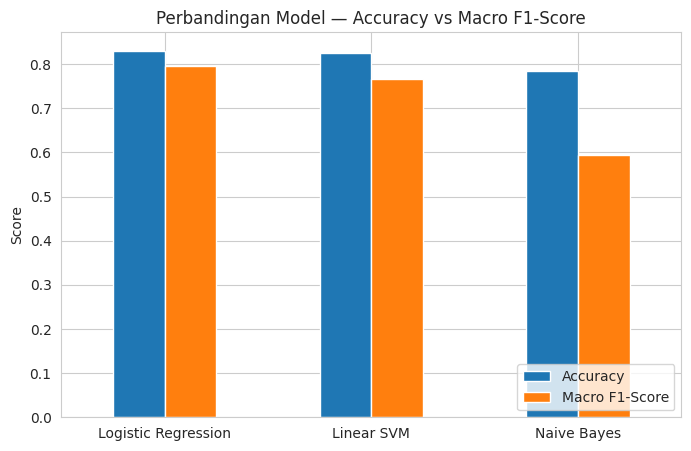

In [10]:
comparison = pd.DataFrame({
    name: {"Accuracy": res["accuracy"], "Macro F1-Score": res["f1_macro"]}
    for name, res in results.items()
}).T.sort_values("Macro F1-Score", ascending=False)

print(comparison)

comparison.plot(kind="bar", figsize=(8, 5))
plt.title("Perbandingan Model — Accuracy vs Macro F1-Score")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()


Model terbaik: Logistic Regression

=== Evaluasi Final di Test Set ===
              precision    recall  f1-score   support

    negative       0.71      0.79      0.75       187
     neutral       0.51      0.54      0.52        63
    positive       0.93      0.87      0.90       350

    accuracy                           0.81       600
   macro avg       0.72      0.73      0.72       600
weighted avg       0.82      0.81      0.81       600



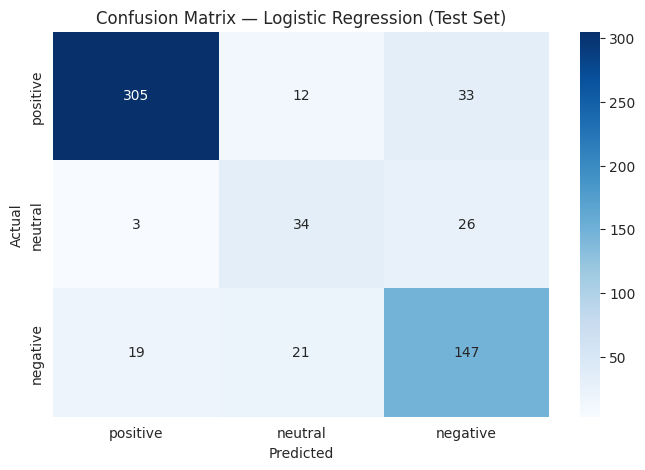

In [11]:
# Pilih model terbaik berdasarkan Macro F1 (lebih adil untuk data imbalanced)
best_model_name = comparison.index[0]
best_model = results[best_model_name]["model"]
print(f"Model terbaik: {best_model_name}")

# Evaluasi final di TEST SET (data yang belum pernah dilihat sama sekali)
y_pred_test = best_model.predict(X_test)
print("\n=== Evaluasi Final di Test Set ===")
print(classification_report(y_test, y_pred_test))

cm = confusion_matrix(y_test, y_pred_test, labels=["positive", "neutral", "negative"])
plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["positive", "neutral", "negative"],
            yticklabels=["positive", "neutral", "negative"])
plt.title(f"Confusion Matrix — {best_model_name} (Test Set)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()


In [12]:
# Error Analysis: lihat contoh teks yang salah diprediksi
test_results = test_df.copy()
test_results["predicted"] = y_pred_test

errors = test_results[test_results["label"] != test_results["predicted"]]
print(f"Jumlah kesalahan prediksi: {len(errors)} dari {len(test_results)} data test ({len(errors)/len(test_results)*100:.1f}%)")
print()
print("Contoh kesalahan prediksi:")
for _, row in errors.head(5).iterrows():
    print(f"Teks     : {row['text'][:120]}")
    print(f"Label asli: {row['label']} | Prediksi: {row['predicted']}")
    print("---")


Jumlah kesalahan prediksi: 114 dari 600 data test (19.0%)

Contoh kesalahan prediksi:
Teks     : mari terus upayakan perubahan , perubahan ke arah yang lebih baik tentunya . moeldoko
Label asli: positive | Prediksi: negative
---
Teks     : banteng penguasa yang tidak tahu adab , melanggar semua aturan sesuka hati , kini sedang merasakan azab yang luar biasa 
Label asli: negative | Prediksi: positive
---
Teks     : tidak indah
Label asli: negative | Prediksi: neutral
---
Teks     : berdikari dalam ekonomi . berdaulat dalam politik . berkepribadian dalam kebudayaan . terlibas reee . polusi mental .
Label asli: neutral | Prediksi: negative
---
Teks     : turunkan anies baswedan dan sandi uno yang tidak becus membereskan jakarta !
Label asli: negative | Prediksi: neutral
---


In [13]:
# Fitur/kata paling berpengaruh untuk tiap kelas (khusus model linear seperti Logistic Regression/SVM)
if best_model_name in ["Logistic Regression", "Linear SVM"]:
    feature_names = np.array(tfidf.get_feature_names_out())
    classes = best_model.classes_

    for i, cls in enumerate(classes):
        coefs = best_model.coef_[i]
        top_idx = np.argsort(coefs)[-15:][::-1]
        print(f"\nKata paling berpengaruh untuk sentimen '{cls}':")
        print(", ".join(feature_names[top_idx]))



Kata paling berpengaruh untuk sentimen 'negative':
macet, mahal, kecewa, cuma, kotor, indosat, benci, apa, agama, kok, padahal, tidak, anjing, orang, bohong

Kata paling berpengaruh untuk sentimen 'neutral':
pilkada, gopay, indomie, demokrat, lihat nya, tewas, fpi, bni, masak, aksi, toyota, hasil, sebut, mohon, bukalapak

Kata paling berpengaruh untuk sentimen 'positive':
enak, tempat, makan, nya, bandung, menu, rasa, harga, sini, nikmat, murah, sangat, cinta, nyaman, pandang


## 6. Business Insight & Use Case

In [14]:
# Simulasi: proporsi sentimen dari sebuah batch komentar baru (contoh use case nyata)
contoh_komentar_baru = [
    "produknya bagus banget, aku suka!",
    "pelayanan lambat dan mengecewakan",
    "biasa aja sih menurutku",
    "worth it banget harganya, recommended!",
    "jangan beli di sini, banyak masalah",
]

contoh_clean = [preprocess(t) for t in contoh_komentar_baru]
contoh_vec = tfidf.transform(contoh_clean)
prediksi = best_model.predict(contoh_vec)

for teks, pred in zip(contoh_komentar_baru, prediksi):
    print(f"[{pred.upper():^10}] {teks}")


[ POSITIVE ] produknya bagus banget, aku suka!
[ NEGATIVE ] pelayanan lambat dan mengecewakan
[ NEGATIVE ] biasa aja sih menurutku
[ POSITIVE ] worth it banget harganya, recommended!
[ NEGATIVE ] jangan beli di sini, banyak masalah


### Ringkasan Insight & Rekomendasi Penggunaan

Model terbaik yang dipilih adalah **Logistic Regression** (Accuracy 83.1%, Macro F1-Score 0.795 di validation set), 
sedikit mengungguli Linear SVM (0.766) dan jauh di atas Naive Bayes (0.594 — anjlok terutama karena gagal 
mengenali kelas `neutral`). Di **test set** (600 data yang sama sekali belum pernah dilihat model), performa 
akhir: **akurasi 81%**, dengan precision/recall per kelas:

| Kelas | Precision | Recall | F1-Score |
|---|---|---|---|
| Positive | 0.93 | 0.87 | 0.90 |
| Negative | 0.71 | 0.79 | 0.75 |
| Neutral | 0.51 | 0.54 | 0.52 |

1. **Kelas `neutral` adalah yang paling sulit diprediksi** (F1 hanya 0.52), jauh di bawah `positive` (0.90) 
   dan `negative` (0.75). Ini konsisten dengan proporsi data: `neutral` hanya ~10% dari total dataset, 
   sehingga model punya lebih sedikit contoh untuk belajar pola bahasanya — ditambah sentimen netral memang 
   secara linguistik lebih ambigu (berada "di antara" positif dan negatif).
   → **Rekomendasi**: jika use case nyata butuh akurasi tinggi khusus di kelas neutral, pertimbangkan 
   mengumpulkan lebih banyak data berlabel neutral, atau gunakan teknik oversampling (SMOTE-like untuk teks) 
   khusus kelas minoritas.

2. **Kata-kata paling berpengaruh sesuai konteks bahasa sehari-hari**: sentimen positive didominasi kata 
   seperti *enak, nikmat, nyaman, murah*; sentimen negative oleh *kecewa, mahal, kotor, benci*. Ini 
   mengonfirmasi model belajar pola yang masuk akal secara linguistik, bukan sekadar noise.

3. **Error analysis** menunjukkan sebagian besar kesalahan terjadi pada: (a) teks pendek tanpa kata kunci 
   sentimen eksplisit (mis. "tidak indah" — negasi pendek yang sulit ditangkap TF-IDF unigram/bigram), 
   dan (b) teks bertopik sosial-politik yang nada sentimennya implisit/sarkastik, bukan literal.

4. **Potensi use case nyata**: pipeline ini bisa diterapkan untuk automasi monitoring sentimen komentar 
   media sosial (TikTok/Instagram) terhadap sebuah brand atau campaign — tim bisa dengan cepat melihat 
   proporsi respon positif vs negatif dari ratusan/ribuan komentar tanpa membaca manual satu per satu, 
   berguna untuk quality control campaign atau deteksi dini crisis PR. Mengingat performa kelas positive/
   negative sudah cukup solid (F1 0.90 dan 0.75), pipeline ini sudah layak untuk use case monitoring 
   tren umum, meski keputusan kritis tetap perlu verifikasi manual terutama untuk kasus bertepi (neutral).

5. **Batasan & pengembangan lanjutan**: model ini menggunakan TF-IDF + model klasik (bukan deep learning/
   transformer), dan dilatih pada subset ~3.000 dari total ±12.700 data yang tersedia untuk efisiensi 
   komputasi. Untuk kebutuhan produksi dengan akurasi lebih tinggi, dua langkah lanjutan yang bisa dicoba: 
   (a) melatih ulang dengan seluruh data yang tersedia, dan (b) fine-tuning model IndoBERT untuk menangkap 
   konteks kalimat secara lebih dalam dibanding pendekatan bag-of-words seperti TF-IDF.
